# Imports

In [47]:
import numpy as np
import pandas as pd
from pathlib import Path
import yaml
import re

from ultralytics import YOLO
import cv2

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import seaborn as sns

np.random.seed(6)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("imports successful")

imports successful


# Config

In [48]:
CONFIG = {
    'dataset_path': 'sign_detection_data',
    'model_name': 'yolov12n',
    'epochs': 100,
    'batch_size': 16,
    'imgsz': 640,
    'patience': 20,
    'device': 0,
    'project': 'sign_detection',
    'name': 'yolov12'
}

dataset_path = Path(CONFIG['dataset_path'])
project_path = Path(CONFIG['project']) / CONFIG['name']

print(f"Dataset Path: {dataset_path}")
print(f"Project Path: {project_path}")
print(f"\nConfiguration:\n")
for key, value in CONFIG.items():
    print(f" {key}: {value}")

Dataset Path: sign_detection_data
Project Path: sign_detection/yolov12

Configuration:

 dataset_path: sign_detection_data
 model_name: yolov12n
 epochs: 100
 batch_size: 16
 imgsz: 640
 patience: 20
 device: 0
 project: sign_detection
 name: yolov12


# Data

In [49]:
yaml_path = dataset_path / 'data.yaml'

if yaml_path.exists():
    with open(yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)
    print("data.yaml loaded")
    print(f"\nDataset Configurations:")
    print(f"    Classes: {data_config['names']}")
    print(f"    Number of classes: {len(data_config['names'])}")

data.yaml loaded

Dataset Configurations:
    Classes: ['Blind-Spot Mirror (Convex)', 'No Entry (One Way)', 'No Through Road (T-Sign)', 'Pedestrian Crossing', 'Roundabout Ahead', 'Stop']
    Number of classes: 6


# Analysis and Visualisation

In [50]:
def analyse_label_distribution(dataset_path, data_config):
    dataset_path = Path(dataset_path)
    class_names = data_config['names']
    num_classes = len(class_names)
    
    splits = ['train', 'val', 'test']
    distribution = {split: np.zeros(num_classes) for split in splits}
    
    for split in splits:
        labels_dir = dataset_path / f'labels/{split}'
        if labels_dir.exists():
            for label_file in labels_dir.glob('*.txt'):
                with open(label_file, 'r') as f:
                    for line in f:
                        class_idx = int(line.split()[0])
                        if 0 <= class_idx < num_classes:
                            distribution[split][class_idx] += 1

    return distribution

try:
    distribution = analyse_label_distribution(dataset_path, data_config)
    print("Class distribution:")
    print(f"{'Class':<30} {'Train':<10} {'Val':<10} {'Test':<10}")
    print("-" * 60)
    for i, class_name in enumerate(data_config['names']):
        print(f"{class_name:<30} {int(distribution['train'][i]):<10} "
              f"{int(distribution['val'][i]):<10} {int(distribution['test'][i]):<10}")
except Exception as e:
    print(f"Could not analyse distribution {e}")

Class distribution:
Class                          Train      Val        Test      
------------------------------------------------------------
Blind-Spot Mirror (Convex)     54         10         9         
No Entry (One Way)             108        12         24        
No Through Road (T-Sign)       28         5          6         
Pedestrian Crossing            102        18         16        
Roundabout Ahead               62         11         6         
Stop                           82         20         16        


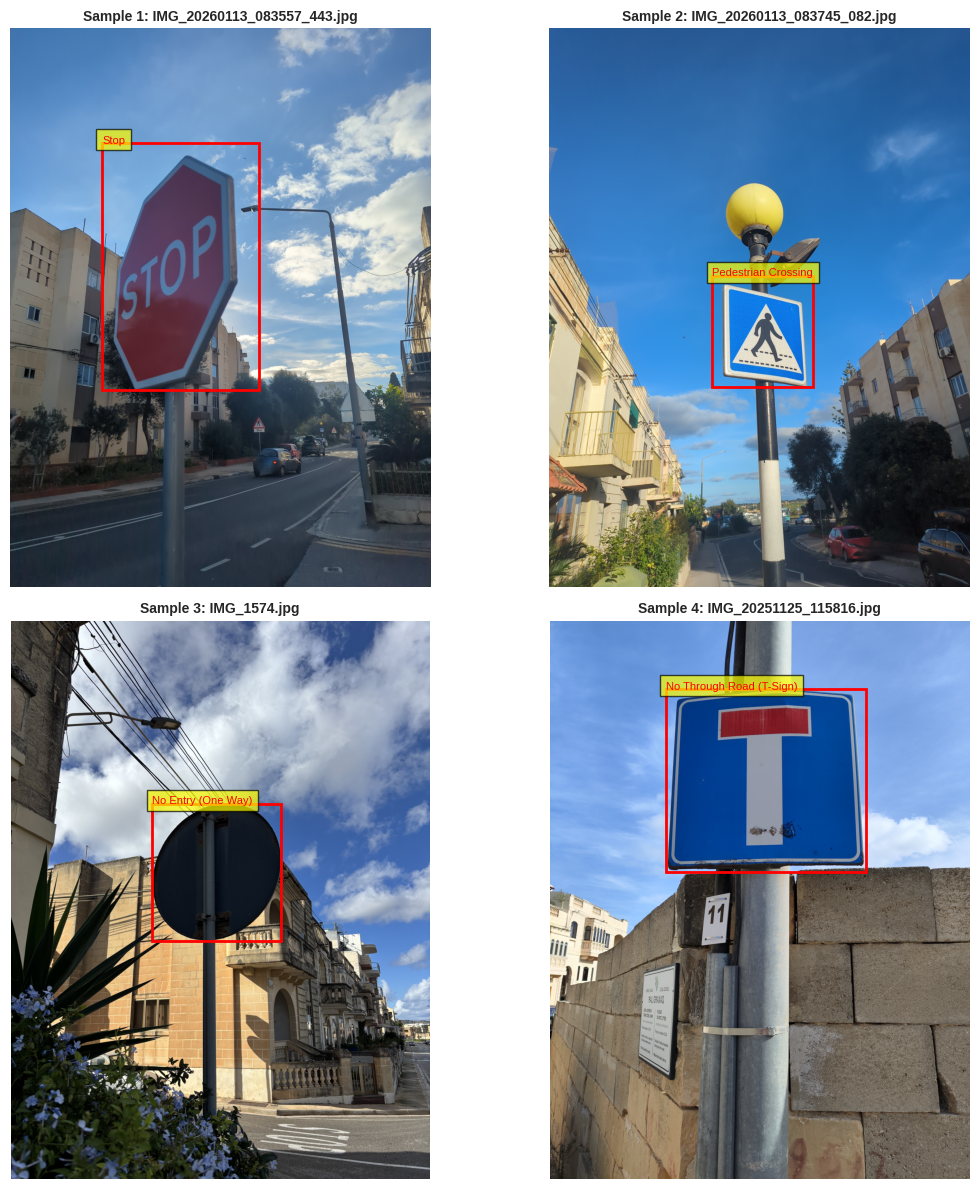

sample annotated images saved


In [51]:
def visualise_sample_images(dataset_path, data_config, num_samples=4):
    train_images = list((Path(dataset_path) / 'images/train').glob('*'))
    train_labels = Path(dataset_path) / 'labels/train'

    if not train_images:
        print("No training images found")
        return

    num_samples = min(num_samples, len(train_images))
    sample_indices = np.random.choice(len(train_images), num_samples, replace=False)

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()

    for idx, sample_idx in enumerate(sample_indices[:4]):
        img_path = train_images[sample_idx]
        label_path = train_labels / f"{img_path.stem}.txt"

        img = Image.open(img_path)
        width, height = img.size

        ax = axes[idx]
        ax.imshow(img)

        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_idx = int(parts[0])
                        x_center, y_center, box_width, box_height = map(float, parts[1:5])

                        x_min = (x_center - box_width/2) * width
                        y_min = (y_center - box_height/2) * height
                        box_w = box_width * width
                        box_h = box_height * height

                        rect = patches.Rectangle((x_min, y_min), box_w, box_h, linewidth=2, edgecolor='r', facecolor='none')

                        ax.add_patch(rect)

                        class_name = data_config['names'][class_idx]
                        ax.text(x_min, y_min-5, class_name, color='red', fontsize=8, bbox = dict(facecolor='yellow', alpha=0.7))

        ax.set_title(f"Sample {idx+1}: {img_path.name}", fontsize=10, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(project_path / 'sample_annotated_images.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("sample annotated images saved")

try:
    visualise_sample_images(dataset_path, data_config, num_samples=4)
except Exception as e:
    print(f"Could not visualise sample images: {e}")
                        

# YOLOv12

## Initialise

In [52]:
print(f"Loading {CONFIG['model_name']} model")
model = YOLO(f"{CONFIG['model_name']}.pt")
print(f"{CONFIG['model_name']} model loaded successfully")
print(f"\nModel Summary:")
model.info()

Loading yolov12n model
yolov12n model loaded successfully

Model Summary:
YOLOv12n summary: 272 layers, 2,603,056 parameters, 0 gradients, 6.7 GFLOPs


(272, 2603056, 0, 6.6535552)

## Train

In [53]:
print("\nStarting YOLOv12 training")
print(f"Configuration:")
print(f"    Epochs: {CONFIG['epochs']}")
print(f"    Batch Size: {CONFIG['batch_size']}")
print(f"    Image Size: {CONFIG['imgsz']}")
print(f"    Patience: {CONFIG['patience']}")

results = model.train(
    data=str(dataset_path / 'data.yaml'),
    epochs=CONFIG['epochs'],
    imgsz=CONFIG['imgsz'],
    batch=CONFIG['batch_size'],
    patience=CONFIG['patience'],
    device=CONFIG['device'],
    project=CONFIG['project'],
    name=CONFIG['name'],
    save=True,
    save_period=10,
    verbose=True,
    seed=1337
)

print("\n Model training finished")


Starting YOLOv12 training
Configuration:
    Epochs: 100
    Batch Size: 16
    Image Size: 640
    Patience: 20
New https://pypi.org/project/ultralytics/8.4.8 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.7 🚀 Python-3.13.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 15948MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=sign_detection_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_

## Get Best Model

In [54]:
if 'results' in locals() and hasattr(results, 'save_dir'):
    actual_save_dir = Path(results.save_dir)
    best_model_path = actual_save_dir / 'weights' / 'best.pt'
    last_model_path = actual_save_dir / 'weights' / 'last.pt'
    print(f"Using training results directory: {actual_save_dir}")
else:
    project_dir = Path(CONFIG['project'])

    if project_dir.exists():
        pattern = re.compile(rf"^{re.escape(CONFIG['name'])}\d*$")
        matching_dirs = [d for d in project_dir.iterdir() if d.is_dir() and pattern.match(d.name)]

        if matching_dirs:
            latest_run = max(matching_dirs, key=lambda x: x.stat().st_mtime)
            best_model_path = latest_run / 'weights' / 'best.pt'
            last_model_path = latest_run / 'weights' / 'last.pt'
            print(f"most recent run: {latest_run.name}")
        else:
            best_model_path = project_dir / CONFIG['name'] / 'weights' / 'best.pt'
            last_model_path = project_dir / CONFIG['name'] / 'weights' / 'best.pt'
            print(" Using default path")
    else:
        best_model_path = Path(CONFIG['project']) / CONFIG['name'] / 'weights' / 'best.pt'
        last_model_path = Path(CONFIG['project']) / CONFIG['name'] / 'weights' / 'best.pt'
        print("Project directory not found")

print(f"\nBest model: {best_model_path}")
print(f"Last Model: {last_model_path}")

Using training results directory: /home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/runs/detect/sign_detection/yolov1221

Best model: /home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/runs/detect/sign_detection/yolov1221/weights/best.pt
Last Model: /home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/runs/detect/sign_detection/yolov1221/weights/last.pt


# Training Metrics

Looking for results at: /home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/runs/detect/sign_detection/yolov1221/results.csv
File exists: True
Loaded 52 epochs of training data
Available columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6', 'lr/pg7']


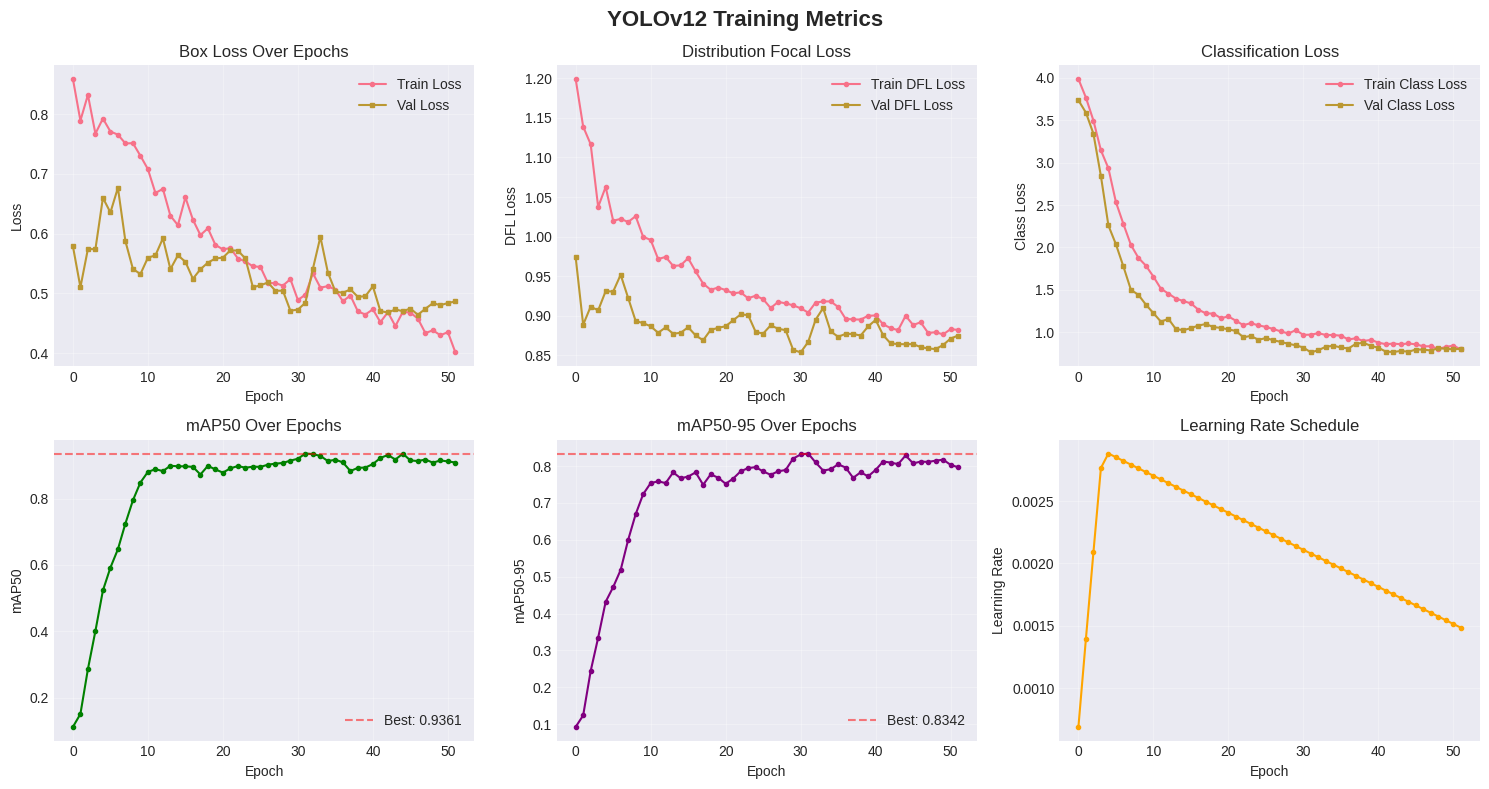

Training metrics saved at /home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/runs/detect/sign_detection/yolov1221/training_metrics.png


In [55]:
if 'results' in locals() and hasattr(results, 'save_dir'):
    results_csv = Path(results.save_dir) / 'results.csv'
else:
    project_dir = Path(CONFIG['project'])

    if project_dir.exists():
        pattern = re.compile(rf"^{re.escape(CONFIG['name'])}\d*$")
        matching_dirs = [d for d in project_dir.iterdir() if d.is_dir() and pattern.match(d.name)]

        if matching_dirs:
            latest_run = max(matching_dirs, key=lambda x: x.stat().st_mtime)
            results_csv = latest_run / 'results.csv'
        else:
            results_csv = project_dir / CONFIG['name'] / 'results.csv'
    else:
        results_csv = Path(CONFIG['project']) / CONFIG['name'] / 'results.csv'

print(f"Looking for results at: {results_csv}")
print(f"File exists: {results_csv.exists()}")

if results_csv.exists():
    df = pd.read_csv(results_csv)
    print(f"Loaded {len(df)} epochs of training data")

    print(f"Available columns: {df.columns.tolist()}")

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('YOLOv12 Training Metrics', fontsize=16, fontweight='bold')

    train_loss_col = 'train/box_loss' if 'train/box_loss' in df.columns else None
    val_loss_col = 'val/box_loss' if 'val/box_loss' in df.columns else None

    if train_loss_col and val_loss_col:
        axes[0, 0].plot(df.index, df[train_loss_col], label='Train Loss', marker='o', markersize=3)
        axes[0, 0].plot(df.index, df[val_loss_col], label='Val Loss', marker='s', markersize=3)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Box Loss Over Epochs')
        axes[0, 0].legend()
        axes[0, 0].grid(alpha=0.3)

    if 'train/dfl_loss' in df.columns:
        axes[0, 1].plot(df.index, df['train/dfl_loss'], label='Train DFL Loss', marker='o', markersize=3)
        if 'val/dfl_loss' in df.columns:
            axes[0, 1].plot(df.index, df['val/dfl_loss'], label='Val DFL Loss', marker='s', markersize=3)
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('DFL Loss')
        axes[0, 1].set_title('Distribution Focal Loss')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.3)

    if 'train/cls_loss' in df.columns:
        axes[0, 2].plot(df.index, df['train/cls_loss'], label='Train Class Loss', marker='o', markersize=3)
        if 'val/cls_loss' in df.columns:
            axes[0, 2].plot(df.index, df['val/cls_loss'], label='Val Class Loss', marker='s', markersize=3)
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('Class Loss')
        axes[0, 2].set_title('Classification Loss')
        axes[0, 2].legend()
        axes[0, 2].grid(alpha=0.3)

    
    map50_col = 'metrics/mAP50(B)'
    
    if map50_col:
        axes[1, 0].plot(df.index, df[map50_col], color='green', marker='o', markersize=3)
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('mAP50')
        axes[1, 0].set_title('mAP50 Over Epochs')
        axes[1, 0].grid(alpha=0.3)
        axes[1, 0].axhline(y=df[map50_col].max(), color='r', linestyle='--', alpha=0.5, label=f'Best: {df[map50_col].max():.4f}')
        axes[1, 0].legend()

    
    map5095_col = 'metrics/mAP50-95(B)'

    if map5095_col:
        axes[1, 1].plot(df.index, df[map5095_col],  color='purple', marker='o', markersize=3)
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('mAP50-95')
        axes[1, 1].set_title('mAP50-95 Over Epochs')
        axes[1, 1].grid(alpha=0.3)
        axes[1, 1].axhline(y=df[map5095_col].max(), color='r', linestyle='--', alpha=0.5, label=f'Best: {df[map5095_col].max():.4f}')
        axes[1, 1].legend()

    
    lr_col = 'lr/pg0'
    if lr_col:
        axes[1, 2].plot(df.index, df[lr_col], color='orange', marker='o', markersize=3)
        axes[1, 2].set_xlabel('Epoch')
        axes[1, 2].set_ylabel('Learning Rate')
        axes[1, 2].set_title('Learning Rate Schedule')
        axes[1, 2].grid(alpha=0.3)
        
    
    plt.tight_layout()
    save_path = results_csv.parent / 'training_metrics.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Training metrics saved at {save_path}")

# Model Validation and Evaluation

In [56]:
if best_model_path.exists():
    best_model = YOLO(str(best_model_path))
    print(f"Best model loaded from {best_model_path}")
else:
    best_model = model
    print("Using last trained model")

Best model loaded from /home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/runs/detect/sign_detection/yolov1221/weights/best.pt


In [57]:
print("Running validation\n")
val_results = best_model.val(
    data=str(dataset_path / 'data.yaml'),
    imgsz=CONFIG['imgsz'],
    batch=CONFIG['batch_size'],
    device=CONFIG['device'],
    verbose=True
)

print("Validation complete")

Running validation

Ultralytics 8.4.7 🚀 Python-3.13.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 15948MiB)
YOLOv12n summary (fused): 159 layers, 2,557,898 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3060.2±1113.9 MB/s, size: 2771.9 KB)
val: Scanning /home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/sign_detection_data/labels/val.cache... 70 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 70/70 16.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 11.0s/it 55.0s.1ss
                   all         70         76      0.921      0.866      0.937       0.83
Blind-Spot Mirror (Convex)         10         10      0.989          1      0.995       0.91
    No Entry (One Way)         12         12      0.812      0.667      0.794      0.585
No Through Road (T-Sign)          5          5      0.956        0.8      0.962      0.923
   Pedestrian Crossi

In [58]:
print("\nValidation Results")
print(f"\nmAP50: {val_results.box.map50:.4f}")
print(f"mAP50-95: {val_results.box.map:.4f}")
print(f"Precision: {val_results.box.mp:.4f}")
print(f"Recall: {val_results.box.mr:.4f}")


print("\nPer-class metrics (Precision / Recall/ AP50 / AP50-95):")
for i, class_name in enumerate(data_config['names']):
    p_val = val_results.box.p[i] if i < len(val_results.box.p) else 0
    r_val = val_results.box.r[i] if i < len(val_results.box.r) else 0
    ap50_val = val_results.box.ap50[i] if i < len(val_results.box.ap50) else 0
    ap_val = val_results.box.ap[i] if i < len(val_results.box.ap) else 0
    print(f"{class_name:<30} {p_val:.4f} / {r_val:.4f} / {ap50_val:.4f} / {ap_val:.4f}")


Validation Results

mAP50: 0.9366
mAP50-95: 0.8297
Precision: 0.9213
Recall: 0.8657

Per-class metrics (Precision / Recall/ AP50 / AP50-95):
Blind-Spot Mirror (Convex)     0.9889 / 1.0000 / 0.9950 / 0.9100
No Entry (One Way)             0.8119 / 0.6667 / 0.7937 / 0.5846
No Through Road (T-Sign)       0.9562 / 0.8000 / 0.9617 / 0.9235
Pedestrian Crossing            0.9160 / 0.8889 / 0.9193 / 0.7458
Roundabout Ahead               0.9056 / 0.9091 / 0.9730 / 0.9281
Stop                           0.9489 / 0.9296 / 0.9770 / 0.8864


In [59]:
# Evaluation metrics table

eval_data = []
for i, class_name in enumerate(data_config['names']):
    p_val = val_results.box.p[i] if i <len(val_results.box.p) else 0
    r_val = val_results.box.r[i] if i <len(val_results.box.r) else 0
    ap50_val = val_results.box.ap50[i] if i < len(val_results.box.ap50) else 0
    ap_val = val_results.box.ap[i] if i < len(val_results.box.ap) else 0
    eval_data.append({
        'Class': class_name,
        'Precision': p_val,
        'Recall': r_val,
        'AP50': ap50_val,
        'AP50-95': ap_val
    })

eval_df = pd.DataFrame(eval_data)
print("\nDetailed Per-Class Eval Metrics:")
print(eval_df.to_string(index=False))

eval_df.to_csv(project_path / 'evaluation_metrics.csv', index=False)
print(f"\n Evaluation metrics saved to {project_path / 'evaluation_metrics.csv'}")



Detailed Per-Class Eval Metrics:
                     Class  Precision   Recall     AP50  AP50-95
Blind-Spot Mirror (Convex)   0.988876 1.000000 0.995000 0.910034
        No Entry (One Way)   0.811937 0.666667 0.793730 0.584564
  No Through Road (T-Sign)   0.956245 0.800000 0.961667 0.923470
       Pedestrian Crossing   0.915992 0.888889 0.919267 0.745807
          Roundabout Ahead   0.905608 0.909091 0.972972 0.928139
                      Stop   0.948925 0.929578 0.976983 0.886431

 Evaluation metrics saved to sign_detection/yolov12/evaluation_metrics.csv


## Per class metrics

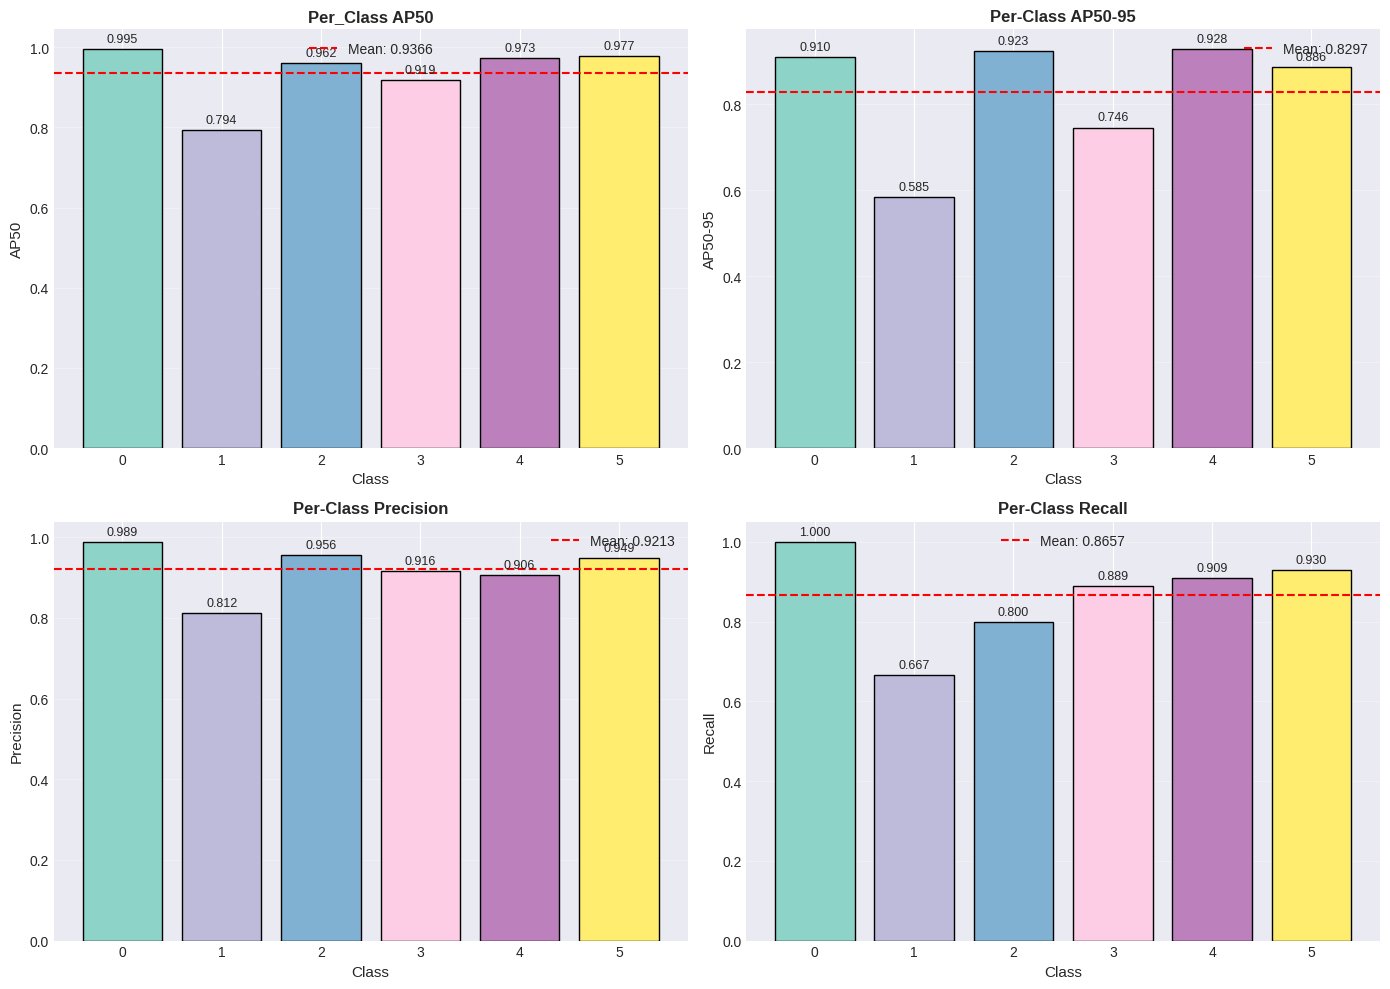

Per class metrics saved


In [60]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = plt.cm.Set3(np.linspace(0, 1, len(data_config['names'])))

# AP50 per class
ap50_vals = [val_results.box.ap50[i] if i < len(val_results.box.ap50) else 0 for i in range(len(data_config['names']))]
axes[0, 0].bar(range(len(data_config['names'])), ap50_vals, color=colors, edgecolor='black')
axes[0, 0].set_xlabel('Class', fontsize=11)
axes[0, 0].set_ylabel('AP50', fontsize=11)
axes[0, 0].set_title('Per_Class AP50', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(range(len(data_config['names'])))
axes[0, 0].set_xticklabels(range(len(data_config['names'])))
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].axhline(y=val_results.box.map50, color='r', linestyle='--', label=f'Mean: {val_results.box.map50:.4f}')
axes[0, 0].legend()
for i, v in enumerate(ap50_vals):
    axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# AP50-95 per class
ap_vals = [val_results.box.ap[i] if i < len(val_results.box.ap) else 0 for i in range(len(data_config['names']))]
axes[0, 1].bar(range(len(data_config['names'])), ap_vals, color=colors, edgecolor='black')
axes[0, 1].set_xlabel('Class', fontsize=11)
axes[0, 1].set_ylabel('AP50-95', fontsize=11)
axes[0, 1].set_title('Per-Class AP50-95', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(range(len(data_config['names'])))
axes[0, 1].set_xticklabels(range(len(data_config['names'])))
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].axhline(y=val_results.box.map, color='r', linestyle='--', label=f'Mean: {val_results.box.map:.4f}')
axes[0, 1].legend()
for i, v in enumerate(ap_vals):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    
# Precision per class
p_vals = [val_results.box.p[i] if i < len(val_results.box.p) else 0 for i in range(len(data_config['names']))]
axes[1, 0].bar(range(len(data_config['names'])), p_vals, color=colors, edgecolor='black')
axes[1, 0].set_xlabel('Class', fontsize=11)
axes[1, 0].set_ylabel('Precision', fontsize=11)
axes[1, 0].set_title('Per-Class Precision', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(range(len(data_config['names'])))
axes[1, 0].set_xticklabels(range(len(data_config['names'])))
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].axhline(y=val_results.box.mp, color='r', linestyle='--', label=f'Mean: {val_results.box.mp:.4f}')
axes[1, 0].legend()
for i, v in enumerate(p_vals):
    axes[1, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# Recall per class
r_vals = [val_results.box.r[i] if i < len(val_results.box.r) else 0 for i in range(len(data_config['names']))]
axes[1, 1].bar(range(len(data_config['names'])), r_vals, color=colors, edgecolor='black')
axes[1, 1].set_xlabel('Class', fontsize=11)
axes[1, 1].set_ylabel('Recall', fontsize=11)
axes[1, 1].set_title('Per-Class Recall', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(range(len(data_config['names'])))
axes[1, 1].set_xticklabels(range(len(data_config['names'])))
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].axhline(y=val_results.box.mr, color='r', linestyle='--', label=f'Mean: {val_results.box.mr:.4f}')
axes[1, 1].legend()
for i, v in enumerate(r_vals):
    axes[1, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(project_path / 'per_class_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("Per class metrics saved")

# Inference Examples

In [68]:
test_images_dir = dataset_path / 'images/test'
test_images = list(test_images_dir.glob('*'))

print(f"Found {len(test_images)} test images")

sample_size = min(4, len(test_images))
sample_images = np.random.choice(test_images, sample_size, replace=False)

sample_images_str = [str(img) for img in sample_images]

results_list = best_model.predict(sample_images_str, conf=0.25, imgsz=CONFIG['imgsz'], verbose=False)
print(f"Inference completed on {len(results_list)} images")

Found 69 test images
Inference completed on 4 images



Image 1: {0: 'Blind-Spot Mirror (Convex)', 1: 'No Entry (One Way)', 2: 'No Through Road (T-Sign)', 3: 'Pedestrian Crossing', 4: 'Roundabout Ahead', 5: 'Stop'}
  - No Entry (One Way): 0.980

Image 2: {0: 'Blind-Spot Mirror (Convex)', 1: 'No Entry (One Way)', 2: 'No Through Road (T-Sign)', 3: 'Pedestrian Crossing', 4: 'Roundabout Ahead', 5: 'Stop'}
  - Pedestrian Crossing: 0.948

Image 3: {0: 'Blind-Spot Mirror (Convex)', 1: 'No Entry (One Way)', 2: 'No Through Road (T-Sign)', 3: 'Pedestrian Crossing', 4: 'Roundabout Ahead', 5: 'Stop'}
  - No Entry (One Way): 0.994

Image 4: {0: 'Blind-Spot Mirror (Convex)', 1: 'No Entry (One Way)', 2: 'No Through Road (T-Sign)', 3: 'Pedestrian Crossing', 4: 'Roundabout Ahead', 5: 'Stop'}
  - Stop: 0.995


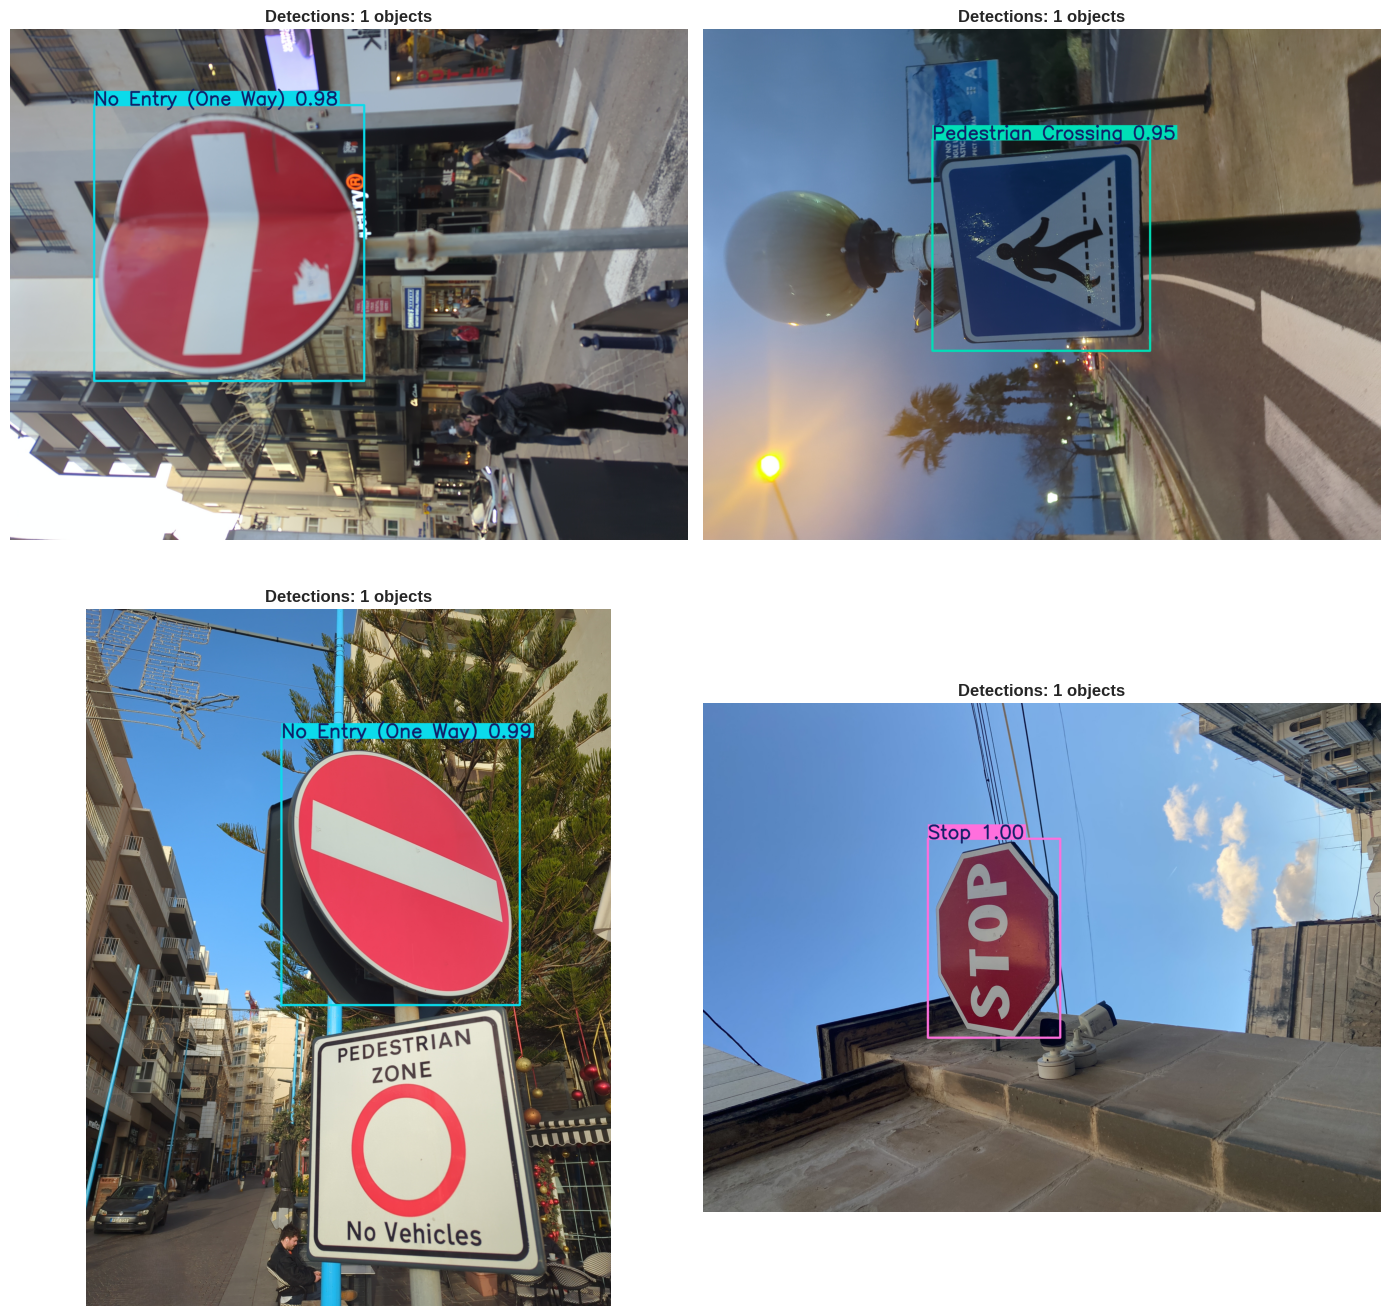


 Inference visualisation saved


In [69]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for idx, result in enumerate(results_list[:4]):
    ax = axes[idx]

    annotated_frame = result.plot()

    ax.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Detections: {len(result.boxes)} objects", fontsize=12, fontweight='bold')
    ax.axis('off')

    if len(result.boxes) > 0:
        print(f"\nImage {idx+1}: {result.names}")
        for box in result.boxes:
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])
            class_name = data_config['names'][class_id]
            print(f"  - {class_name}: {confidence:.3f}")

plt.tight_layout()
plt.savefig(project_path / 'inference_examples.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n Inference visualisation saved")

## Inference Analysis and Statistics

In [70]:
def analyse_detections(image_paths, model, data_config, conf_threshold=0.25):
    detections_data = []
    class_counts = {i: 0 for i in range(len(data_config['names']))}

    for img_path in image_paths:
        results = model.predict(str(img_path), conf=conf_threshold, verbose=False)
        result = results[0]

        for box in result.boxes:
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])
            class_counts[class_id] += 1

            detections_data.append({
                'Image': img_path.name,
                'Class': data_config['names'][class_id],
                'Confidence': confidence,
                'Class_ID': class_id
            })

    return detections_data, class_counts

test_images_dir = dataset_path / 'images/test'
if test_images_dir.exists() and len(list(test_images_dir.glob('*'))) > 0:
    test_images = list(test_images_dir.glob('*'))

else:
    test_images = list((dataset_path / 'images/val').glob('*'))

print(f"Analysing {len(test_images)} images")
detections_data, class_counts = analyse_detections(test_images, best_model, data_config)

print(f"\nTotal detections: {len(detections_data)}")
print(f"Average detections per image: {len(detections_data) / len(test_images):.2f}")
print(f"\nDetections by class:")
for class_id, count in class_counts.items():
    if count > 0:
        print(f"   {data_config['names'][class_id]}: {count}")

Analysing 69 images

Total detections: 81
Average detections per image: 1.17

Detections by class:
   Blind-Spot Mirror (Convex): 8
   No Entry (One Way): 25
   No Through Road (T-Sign): 7
   Pedestrian Crossing: 18
   Roundabout Ahead: 8
   Stop: 15



Detection Summary Statistics:

Confidence Statistics:
    Mean: 0.8565
    Std Dev: 0.2178
    Min: 0.2760
    Max: 0.9981


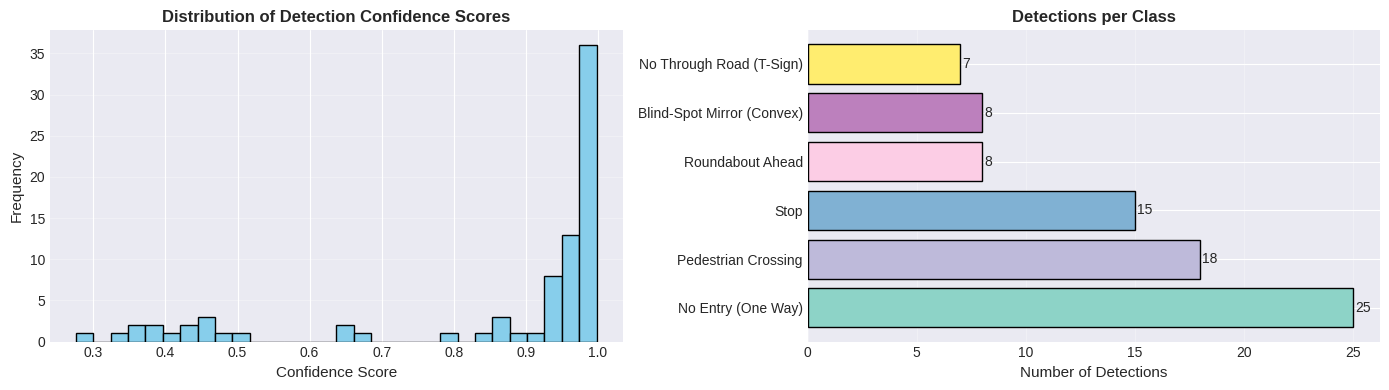

Detection statistics saved to sign_detection/yolov12/detections.csv


In [71]:
detections_df = pd.DataFrame(detections_data)

if len(detections_df) > 0:
    print("\nDetection Summary Statistics:")
    print(f"\nConfidence Statistics:")
    print(f"    Mean: {detections_df['Confidence'].mean():.4f}")
    print(f"    Std Dev: {detections_df['Confidence'].std():.4f}")
    print(f"    Min: {detections_df['Confidence'].min():.4f}")
    print(f"    Max: {detections_df['Confidence'].max():.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(detections_df['Confidence'], bins=30, color='skyblue', edgecolor='black')
    axes[0].set_xlabel('Confidence Score', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].set_title('Distribution of Detection Confidence Scores', fontsize=12, fontweight='bold')
    axes[0].grid(axis='y',alpha=0.3)

    class_det = detections_df['Class'].value_counts()
    colors = plt.cm.Set3(np.linspace(0, 1, len(class_det)))
    axes[1].barh(class_det.index, class_det.values, color=colors, edgecolor='black')
    axes[1].set_xlabel('Number of Detections', fontsize=11)
    axes[1].set_title('Detections per Class', fontsize=12, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)

    for i, (adx, v) in enumerate(zip(class_det.index, class_det.values)):
        axes[1].text(v + 0.1, i, str(int(v)), va='center')

    plt.tight_layout()
    plt.savefig(project_path / 'detection_statistics.png', dpi=300, bbox_inches='tight')
    plt.show()
    detections_df.to_csv(project_path / 'detections.csv', index=False)
    print(f"Detection statistics saved to {project_path / 'detections.csv'}")

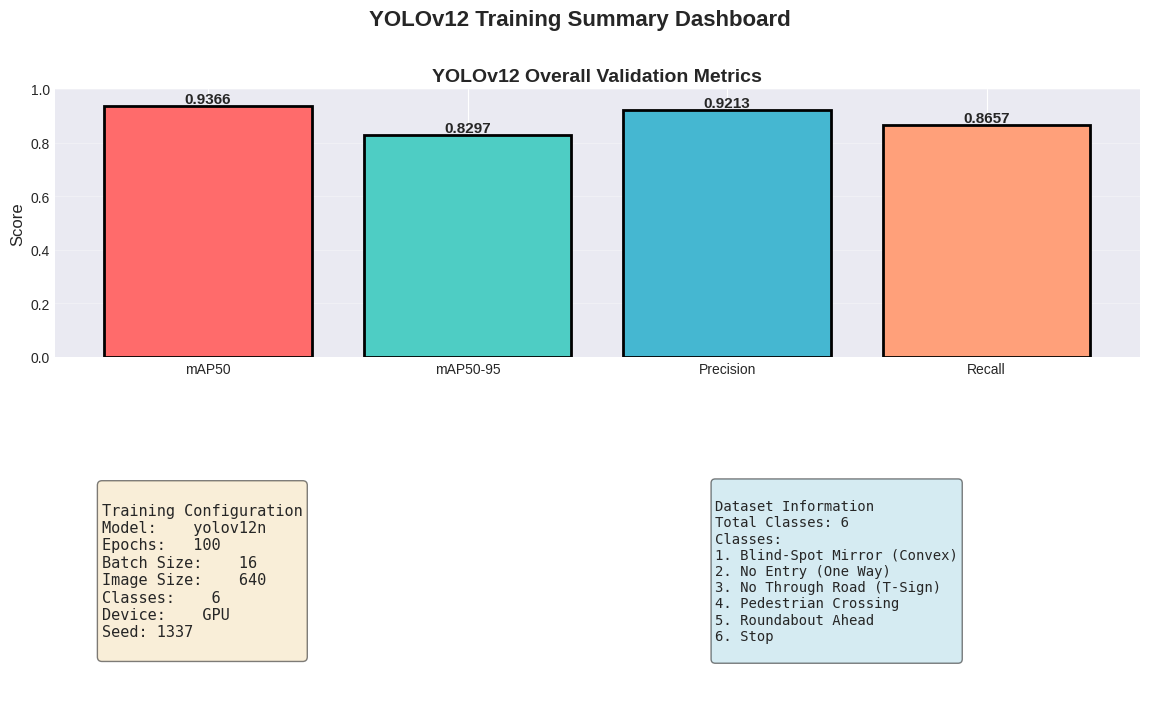

Training summary saved


In [72]:
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0,:])
metrics_names = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
metrics_values = [val_results.box.map50, val_results.box.map, val_results.box.mp, val_results.box.mr]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = ax1.bar(metrics_names, metrics_values, color=colors, edgecolor='black', linewidth=2)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('YOLOv12 Overall Validation Metrics', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{value:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')


ax2 = fig.add_subplot(gs[1, 0])
ax2.axis('off')
config_text = f"""
Training Configuration
Model:    {CONFIG['model_name']}
Epochs:   {CONFIG['epochs']}
Batch Size:    {CONFIG['batch_size']}
Image Size:    {CONFIG['imgsz']}
Classes:    {len(data_config['names'])}
Device:    {'GPU' if CONFIG['device'] >= 0 else 'CPU'}
Seed: 1337
"""
ax2.text(0.1, 0.5, config_text, fontsize=11, family='monospace', verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
dataset_text = f"""
Dataset Information
Total Classes: {len(data_config['names'])}
Classes:
"""
for i, class_name in enumerate(data_config['names'], 1):
    dataset_text += f"{i}. {class_name}\n"

ax3.text(0.1, 0.5, dataset_text, fontsize=10, family='monospace', verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.suptitle('YOLOv12 Training Summary Dashboard', fontsize=16, fontweight='bold', y=0.98)
plt.savefig(project_path / 'training_summary_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("Training summary saved")

# Export and Save Model

In [73]:
print("Exporting model")

export_formats = ['torchscript', 'onnx']

for export_format in export_formats:
    print(f"Exporting to {export_format}")
    best_model.export(format=export_format, imgsz=CONFIG['imgsz'])

print("\nModel export complete")

Exporting model
Exporting to torchscript
Ultralytics 8.4.7 🚀 Python-3.13.11 torch-2.8.0+cu128 CPU (AMD EPYC 8124P 16-Core Processor)

PyTorch: starting from '/home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/runs/detect/sign_detection/yolov1221/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (5.2 MB)

TorchScript: starting export with torch 2.8.0+cu128...
TorchScript: export success ✅ 2.0s, saved as '/home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/runs/detect/sign_detection/yolov1221/weights/best.torchscript' (10.5 MB)

Export complete (2.7s)
Results saved to /home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/runs/detect/sign_detection/yolov1221/weights
Predict:         yolo predict task=detect model=/home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/runs/detect/sign_detection/yolov1221/weights/best.torchscript imgsz=640 
Validate:        yolo val task=detect model=/home/mbb/Do

/home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/venv/lib/python3.13/site-packages/torch/onnx/utils.py:1397: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.82...
ONNX: export success ✅ 1.3s, saved as '/home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/runs/detect/sign_detection/yolov1221/weights/best.onnx' (10.1 MB)

Export complete (1.4s)
Results saved to /home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/runs/detect/sign_detection/yolov1221/weights
Predict:         yolo predict task=detect model=/home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/runs/detect/sign_detection/yolov1221/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/home/mbb/Documents/Uni/Uni/Third Year/vision/ass/complete/unvibed/runs/detect/sign_detection/yolov1221/weights/best.onnx imgsz=640 data=sign_detection_data/data.yaml  
Visualize:       https://netron.app

Model export complete


# Final Report

In [74]:
final_report = f"""
2a - Sign detection using YOLOv12

Model Architectiure
Base Model: {CONFIG['model_name']}
Number of Classes: {len(data_config['names'])}
Classes: {', '.join(data_config['names'])}


Training Details

Total Epochs: {CONFIG['epochs']}
Batch Size: {CONFIG['batch_size']}
Image Input Size: {CONFIG['imgsz']}x{CONFIG['imgsz']}
Optimisation: Early Sopping (Patience: {CONFIG['patience']})
Random Seed: 1337


Validation Performance

Mean Average Precision @0.50: {val_results.box.map50:.4f}
Mean Average Precision @0.50-0.95: {val_results.box.map:.4f}
Precision: {val_results.box.mp:.4f}
Recall: {val_results.box.mr:.4f}


Per-Class Preformance Metrics

{'Class':<30} {'Precision':<15} {'Recall':<15} {'AP50':<15} {'AP50-95':<15}
"""

for i, class_name in enumerate(data_config['names']):
    p_val = val_results.box.p[i] if i < len(val_results.box.p) else 0
    r_val = val_results.box.r[i] if i < len(val_results.box.r) else 0
    ap50_val = val_results.box.ap50[i] if i < len(val_results.box.ap50) else 0
    ap_val = val_results.box.ap[i] if i < len(val_results.box.ap) else 0
    final_report += f"{class_name:<30} {p_val:<15.4f} {r_val:<15.4f} {ap50_val:<15.4f} {ap_val:<15.4f}\n"

final_report += f"""


Findings

- The YOLOv12 model successfully learned to detect 6 traffic sign types
- Overall mAP50-95 results indicate strong detection performance
- Per-class analysis shows varied performance across different sign types
- Early stopping helped prevent overfitting while maintaining model performance
"""

print(final_report)

with open(project_path / 'final_report.txt', 'w') as f:
    f.write(final_report)

print(f"\n Summary saved to {project_path / 'final_report.txt'}")


2a - Sign detection using YOLOv12

Model Architectiure
Base Model: yolov12n
Number of Classes: 6
Classes: Blind-Spot Mirror (Convex), No Entry (One Way), No Through Road (T-Sign), Pedestrian Crossing, Roundabout Ahead, Stop


Training Details

Total Epochs: 100
Batch Size: 16
Image Input Size: 640x640
Optimisation: Early Sopping (Patience: 20)
Random Seed: 1337


Validation Performance

Mean Average Precision @0.50: 0.9366
Mean Average Precision @0.50-0.95: 0.8297
Precision: 0.9213
Recall: 0.8657


Per-Class Preformance Metrics

Class                          Precision       Recall          AP50            AP50-95        
Blind-Spot Mirror (Convex)     0.9889          1.0000          0.9950          0.9100         
No Entry (One Way)             0.8119          0.6667          0.7937          0.5846         
No Through Road (T-Sign)       0.9562          0.8000          0.9617          0.9235         
Pedestrian Crossing            0.9160          0.8889          0.9193          0.745